In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
df_2019 =pd.read_csv("../new_model/2019_pred.csv",index_col=0)
df_ssp1 =pd.read_csv("../new_model/ssp126_pred.csv",index_col=0)
df_ssp2 =pd.read_csv("../new_model/ssp245_pred.csv",index_col=0)
df_ssp5 =pd.read_csv("../new_model/ssp585_pred.csv",index_col=0)

In [3]:
df_grids =pd.read_csv('../grid_data/grids.csv',index_col=0)

In [4]:
annual_2019 = df_2019.groupby('index')['prediction_1'].mean().reset_index()
annual_2019 =pd.merge(annual_2019,df_grids,on='index')
annual_ssp2 = df_ssp2.groupby('index')['prediction_1'].mean().reset_index()
annual_ssp2 =pd.merge(annual_ssp2,df_grids,on='index')
annual_ssp1 = df_ssp1.groupby('index')['prediction_1'].mean().reset_index()
annual_ssp1 =pd.merge(annual_ssp1,df_grids,on='index')
annual_ssp5 = df_ssp5.groupby('index')['prediction_1'].mean().reset_index()
annual_ssp5 =pd.merge(annual_ssp5,df_grids,on='index')

In [5]:
annual_2019.set_index(['lat', 'lon'], inplace=True)
xr_2019 = annual_2019.to_xarray()
annual_ssp2.set_index(['lat', 'lon'], inplace=True)
xr_ssp2 = annual_ssp2.to_xarray()
annual_ssp1.set_index(['lat', 'lon'], inplace=True)
xr_ssp1 = annual_ssp1.to_xarray()
annual_ssp5.set_index(['lat', 'lon'], inplace=True)
xr_ssp5 = annual_ssp5.to_xarray()

In [6]:
#ds_2018 = xr_2018.rename({'obs_prediction': '2018'})
ds_2019 = xr_2019.rename({'prediction_1': '2019'})
ds_ssp2 = xr_ssp2.rename({'prediction_1':'ssp2'})
ds_ssp1 = xr_ssp1.rename({'prediction_1':'ssp1'})
ds_ssp5 = xr_ssp5.rename({'prediction_1':'ssp5'})
#ds_merged = ds_2019.merge(ds_2018)
ds_merged = ds_2019.merge(ds_ssp2)
ds_merged = ds_merged.merge(ds_ssp1)
ds_merged = ds_merged.merge(ds_ssp5)

print(ds_merged)

<xarray.Dataset> Size: 21kB
Dimensions:  (lat: 18, lon: 28)
Coordinates:
  * lat      (lat) float64 144B 47.5 47.93 48.36 48.79 ... 53.96 54.39 54.82
  * lon      (lon) float64 224B 2.944 3.375 3.805 4.236 ... 13.71 14.14 14.57
Data variables:
    index    (lat, lon) float64 4kB nan nan nan nan nan ... nan nan nan nan nan
    2019     (lat, lon) float64 4kB nan nan nan nan nan ... nan nan nan nan nan
    ssp2     (lat, lon) float64 4kB nan nan nan nan nan ... nan nan nan nan nan
    ssp1     (lat, lon) float64 4kB nan nan nan nan nan ... nan nan nan nan nan
    ssp5     (lat, lon) float64 4kB nan nan nan nan nan ... nan nan nan nan nan


/tmp/ipykernel_4004287/4015730304.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # 左侧留空给子图，右侧留空给颜色条


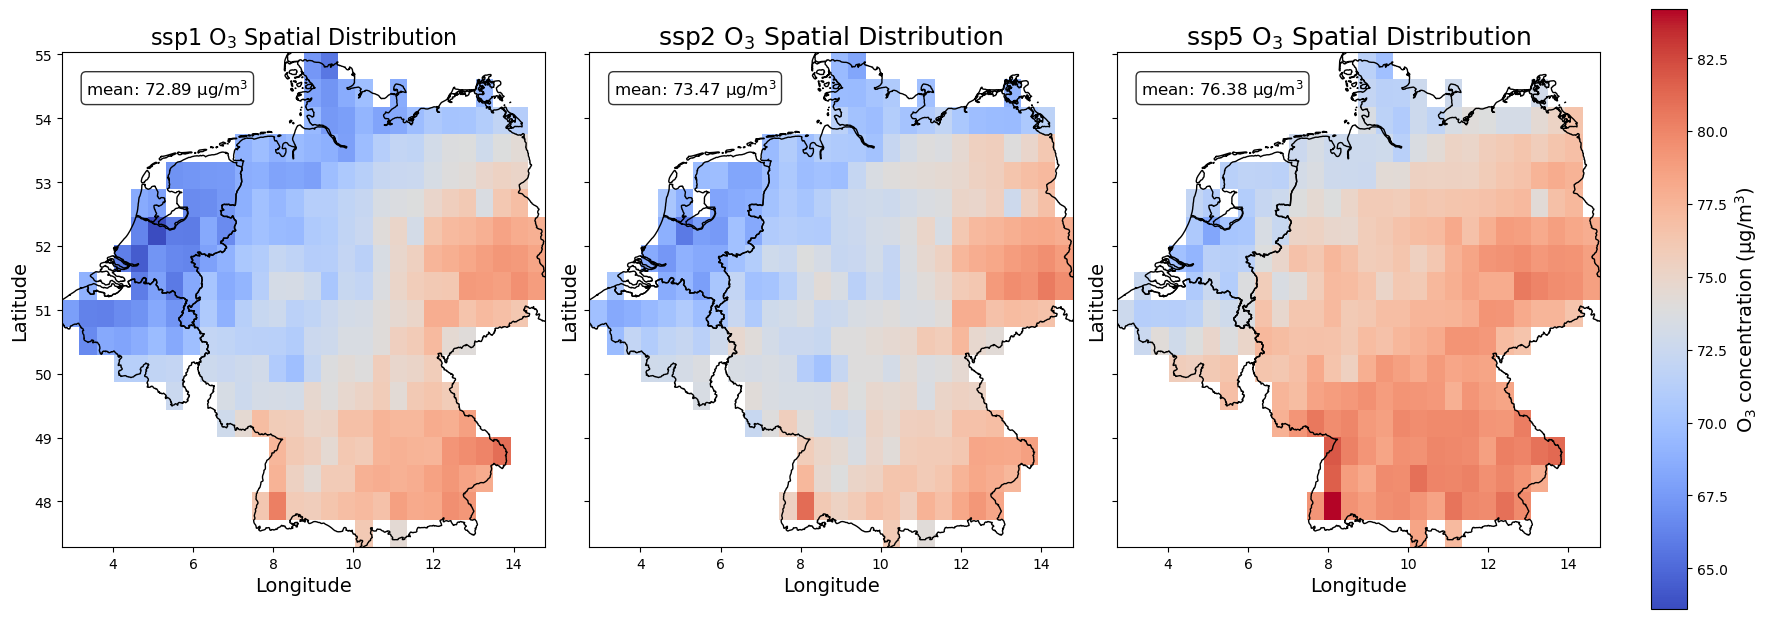

In [7]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import geopandas as gpd

shapefile = gpd.read_file('../map/germany.shp')

ds_ssp1 = ds_merged['ssp1']
ds_ssp2 = ds_merged['ssp2']
ds_ssp5 = ds_merged['ssp5']

vmin = np.nanmin([ds_ssp2.values, ds_ssp1.values, ds_ssp5.values])
vmax = np.nanmax([ds_ssp2.values, ds_ssp1.values, ds_ssp5.values])
cmap = 'coolwarm'


mean_ssp1 = np.nanmean(ds_ssp1.values)  
mean_ssp2 = np.nanmean(ds_ssp2.values)  
mean_ssp5 = np.nanmean(ds_ssp5.values)  

fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

im1 = ds_ssp1.plot(ax=axs[0], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axs[0].set_title('ssp1 O$_3$ Spatial Distribution', fontsize=16)
shapefile.plot(ax=axs[0], edgecolor='black', facecolor='none')
axs[0].text(
    0.05, 0.95,                
    f'mean: {mean_ssp1:.2f} μg/m$^3$',  
    transform=axs[0].transAxes, 
    fontsize=12,
    verticalalignment='top',   
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)  
)
axs[0].set_xlabel('Longitude',fontsize=14)
axs[0].set_ylabel('Latitude',fontsize=14)


im2 = ds_ssp2.plot(ax=axs[1], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axs[1].set_title('ssp2 O$_3$ Spatial Distribution', fontsize=18)
shapefile.plot(ax=axs[1], edgecolor='black', facecolor='none')
axs[1].text(
    0.05, 0.95,
    f'mean: {mean_ssp2:.2f} μg/m$^3$',
    transform=axs[1].transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axs[1].set_xlabel('Longitude',fontsize=14)
axs[1].set_ylabel('Latitude',fontsize=14)

im3 = ds_ssp5.plot(ax=axs[2], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axs[2].set_title('ssp5 O$_3$ Spatial Distribution', fontsize=18)
shapefile.plot(ax=axs[2], edgecolor='black', facecolor='none')
axs[2].text(
    0.05, 0.95,
    f'mean: {mean_ssp5:.2f} μg/m$^3$',
    transform=axs[2].transAxes,
    fontsize=12,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
axs[2].set_xlabel('Longitude',fontsize=14)
axs[2].set_ylabel('Latitude',fontsize=14)

cbar_ax = fig.add_axes([0.92, 0.00, 0.02, 1.0])  
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label('O$_3$ concentration (μg/m$^3$)', fontsize=14)

plt.tight_layout(rect=[0, 0, 0.9, 1])  

plt.show()

/tmp/ipykernel_4004287/3855298021.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # 确保子图和颜色条不重叠


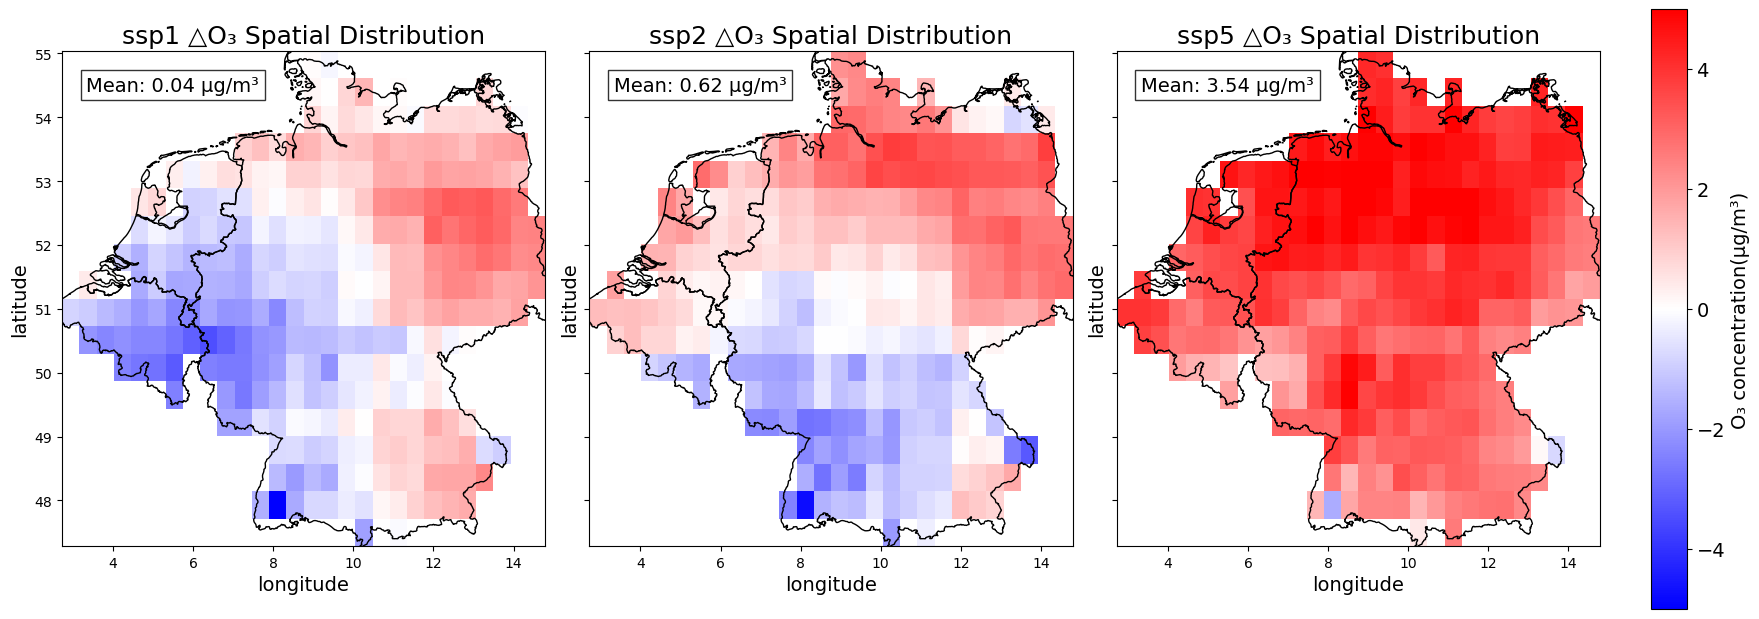

In [8]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import geopandas as gpd

shapefile = gpd.read_file('../map/germany.shp')

ds_ssp1 = ds_merged['ssp1']-ds_merged['2019']
ds_ssp2 = ds_merged['ssp2']-ds_merged['2019']
ds_ssp5 = ds_merged['ssp5']-ds_merged['2019']

vmin = -5
vmax = 5
cmap = 'bwr'

mean1=ds_ssp1.mean()
mean2=ds_ssp2.mean()
mean3=ds_ssp5.mean()

fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

im1 = ds_ssp1.plot(ax=axs[0], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axs[0].set_title('ssp1 △O₃ Spatial Distribution',fontsize=18)
shapefile.plot(ax=axs[0], edgecolor='black', facecolor='none')
axs[0].text(0.05, 0.95, f'Mean: {mean1:.2f} μg/m³', fontsize=14,transform=axs[0].transAxes,
            verticalalignment='top',bbox=dict(facecolor='white', alpha=0.8))
axs[0].set_xlabel('longitude', fontsize=14)  
axs[0].set_ylabel('latitude', fontsize=14)  

im2 = ds_ssp2.plot(ax=axs[1], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axs[1].set_title('ssp2 △O₃ Spatial Distribution',fontsize=18)
shapefile.plot(ax=axs[1], edgecolor='black', facecolor='none')
axs[1].text(0.05, 0.95, f'Mean: {mean2:.2f} μg/m³', fontsize=14,transform=axs[1].transAxes,
            verticalalignment='top',bbox=dict(facecolor='white', alpha=0.8))
axs[1].set_xlabel('longitude', fontsize=14)  
axs[1].set_ylabel('latitude', fontsize=14)  

im3 = ds_ssp5.plot(ax=axs[2], cmap=cmap, add_colorbar=False, vmin=vmin, vmax=vmax)
axs[2].set_title('ssp5 △O₃ Spatial Distribution',fontsize=18)
shapefile.plot(ax=axs[2], edgecolor='black', facecolor='none')
axs[2].text(0.05, 0.95, f'Mean: {mean3:.2f} μg/m³',fontsize=14, transform=axs[2].transAxes,
            verticalalignment='top',bbox=dict(facecolor='white', alpha=0.8))
axs[2].set_xlabel('longitude', fontsize=14)  
axs[2].set_ylabel('latitude', fontsize=14)  

cbar_ax = fig.add_axes([0.92, 0.00, 0.02,1.0])
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('O₃ concentration(μg/m³)',fontsize=14)

plt.tight_layout(rect=[0, 0, 0.9, 1])  

plt.show()

In [9]:
days_ssp1 =df_ssp1[df_ssp1['prediction_1'] > 120].groupby('index').size()
days_ssp1 = days_ssp1.reset_index(name='days_over_120')
days_ssp2 =df_ssp2[df_ssp2['prediction_1'] > 120].groupby('index').size()
days_ssp2 = days_ssp2.reset_index(name='days_over_120')
days_ssp5 =df_ssp5[df_ssp5['prediction_1'] > 120].groupby('index').size()
days_ssp5 = days_ssp5.reset_index(name='days_over_120')

In [10]:
day_ssp1 =pd.merge(days_ssp1,df_grids,on='index')
day_ssp2 =pd.merge(days_ssp2,df_grids,on='index')
day_ssp5 =pd.merge(days_ssp5,df_grids,on='index')
day_ssp2.set_index(['lat', 'lon'], inplace=True)
day_ssp2 =day_ssp2.to_xarray()
day_ssp1.set_index(['lat', 'lon'], inplace=True)
day_ssp1 =day_ssp1.to_xarray()
day_ssp5.set_index(['lat', 'lon'], inplace=True)
day_ssp5 =day_ssp5.to_xarray()

/tmp/ipykernel_4004287/1554205751.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # 确保子图和颜色条不重叠


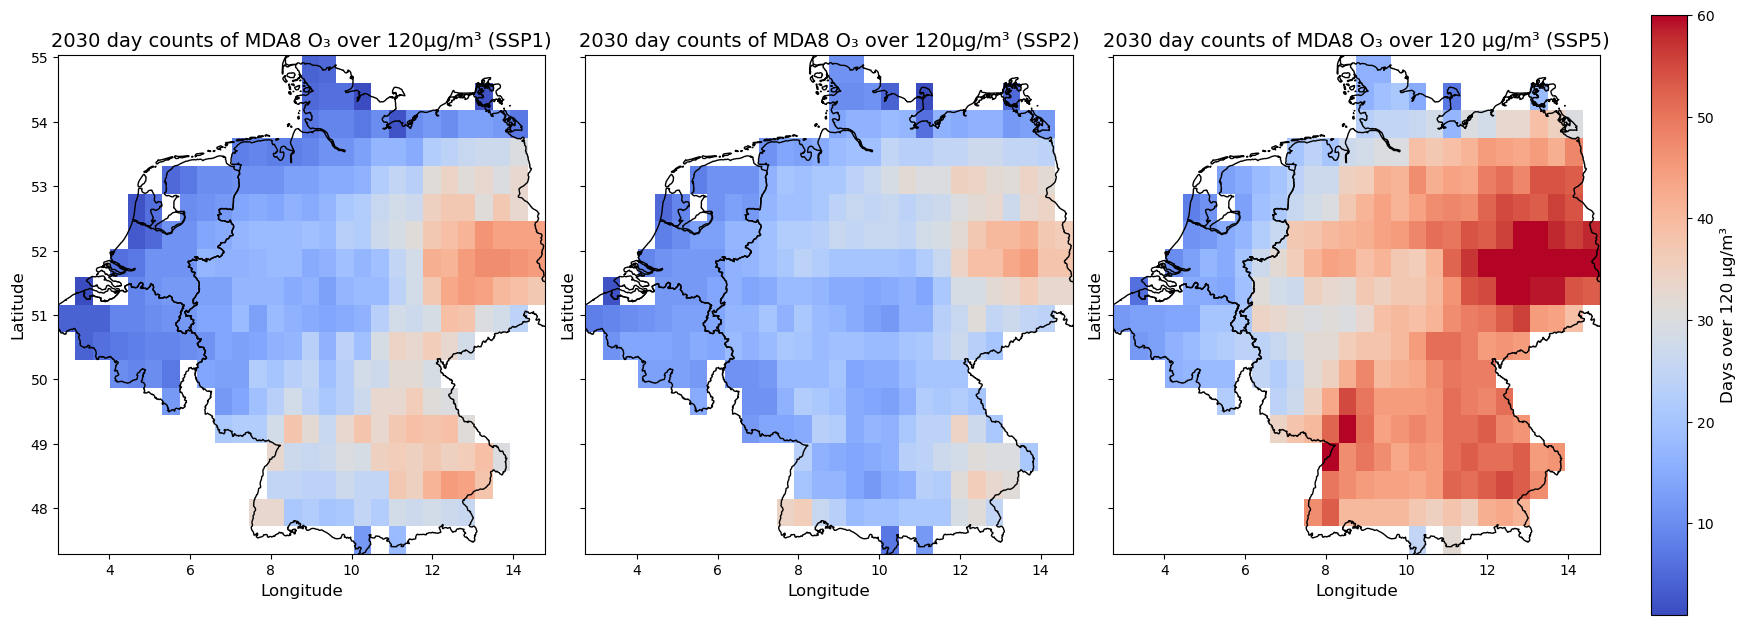

In [11]:
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import numpy as np

o3_data_ssp1 = day_ssp1['days_over_120']
o3_data_ssp2 = day_ssp2['days_over_120']
o3_data_ssp5 = day_ssp5['days_over_120']

vmin = np.nanmin([o3_data_ssp2.values, o3_data_ssp1.values, o3_data_ssp5.values])
vmax =60
shapefile = gpd.read_file('../map/germany.shp')

fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

im1 = o3_data_ssp1.plot(ax=axs[0], x='lon', y='lat', cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
axs[0].set_title('2030 day counts of MDA8 O₃ over 120μg/m³ (SSP1)',fontsize=14)
shapefile.plot(ax=axs[0], edgecolor='black', facecolor='none')
axs[0].set_xlabel('Longitude', fontsize=12)  
axs[0].set_ylabel('Latitude', fontsize=12)   

im2 = o3_data_ssp2.plot(ax=axs[1], x='lon', y='lat', cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
axs[1].set_title('2030 day counts of MDA8 O₃ over 120μg/m³ (SSP2)',fontsize=14)
shapefile.plot(ax=axs[1], edgecolor='black', facecolor='none')
axs[1].set_xlabel('Longitude', fontsize=12)  
axs[1].set_ylabel('Latitude', fontsize=12)   

im3 = o3_data_ssp5.plot(ax=axs[2], x='lon', y='lat', cmap='coolwarm', add_colorbar=False, vmin=vmin, vmax=vmax)
axs[2].set_title('2030 day counts of MDA8 O₃ over 120 μg/m³ (SSP5)',fontsize=14)
shapefile.plot(ax=axs[2], edgecolor='black', facecolor='none')
axs[2].set_xlabel('Longitude', fontsize=12)  
axs[2].set_ylabel('Latitude', fontsize=12)   

cbar_ax = fig.add_axes([0.92, 0.00, 0.02,1.0]) 
cbar = fig.colorbar(im1, cax=cbar_ax)
cbar.set_label('Days over 120 μg/m³',fontsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 1])  

plt.show()

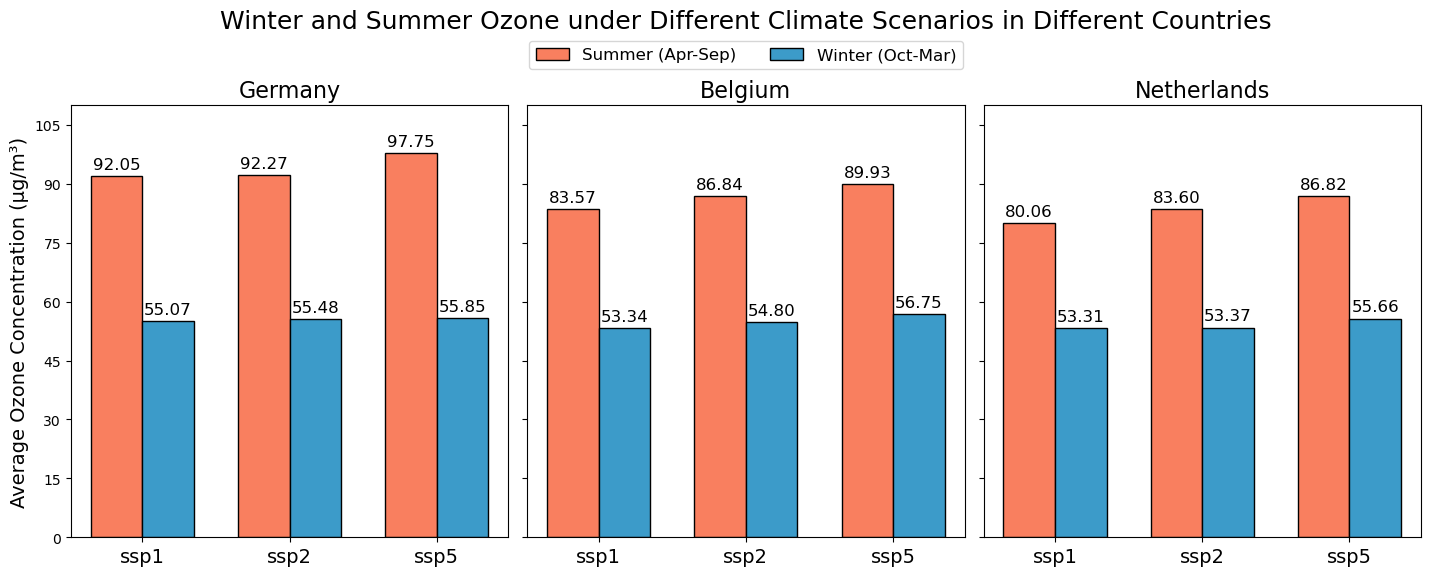

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import MaxNLocator

data = {
    "Country": ["Germany", "Germany", "Germany", "Belgium", "Belgium", "Belgium", "Netherlands", "Netherlands", "Netherlands"],
    "Scenario": ["ssp1", "ssp2", "ssp5"] * 3,
    "Summer": [92.05, 92.27, 97.75, 83.57, 86.84, 89.93, 80.06, 83.60, 86.82],
    "Winter": [55.07, 55.48, 55.85, 53.34, 54.80, 56.75, 53.31, 53.37, 55.66]
}
df = pd.DataFrame(data)

countries = df["Country"].unique()
scenarios = df["Scenario"].unique()
n_scenarios = len(scenarios)

plt.style.use('default')
fig, axs = plt.subplots(1, 3, figsize=(15, 6), sharey=True)  

fig.suptitle("Winter and Summer Ozone under Different Climate Scenarios in Different Countries",
             fontsize=18, y=0.98)  


bar_width = 0.35  
x = np.arange(n_scenarios)  
colors = ['#F97F5F', '#3C9BC9']  


for i, country in enumerate(countries):
    ax = axs[i]
    country_data = df[df["Country"] == country]
    
    bars_summer = ax.bar(x - bar_width/2, country_data["Summer"], width=bar_width, 
                         label="Summer (Apr-Sep)", color=colors[0], edgecolor='black')
    bars_winter = ax.bar(x + bar_width/2, country_data["Winter"], width=bar_width, 
                         label="Winter (Oct-Mar)", color=colors[1], edgecolor='black')
    
    
    ax.set_title(country, fontsize=16)
    
    
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, fontsize=14)
    
    
    if i == 0:
        ax.set_ylabel("Average Ozone Concentration (μg/m³)", fontsize=14)
    
    
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))  
    
    
    for bar in bars_summer:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.2f}', ha='center', va='bottom', fontsize=12)
    for bar in bars_winter:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.2f}', ha='center', va='bottom', fontsize=12)


handles, labels = axs[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='upper center',        
    bbox_to_anchor=(0.5, 0.93),
    fontsize=12,               
    frameon=True,              
    borderaxespad=0.1,
    ncol=2                     
)

plt.tight_layout()

plt.subplots_adjust(top=0.82, left=0.05, right=0.95, bottom=0.1)


plt.show()